In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast


In [ ]:
def exploding_genre(data):
    data = data.copy()
    # converting string of a list into literal list
    data['genres'] = data['genres'].apply(ast.literal_eval)

    # filtering out the genre animation, due to all movies being animation movies
    data['genres'] = data['genres'].apply(lambda g: [x for x in g if x != "Animation" and x != "TV Movie"])
    
    # breaking up genre animation, due to all movies being animation movies
    genres = data['genres'].explode()

    # assigning values to each genre to quantify them
    genre_dummies = pd.get_dummies(genres)
    genre_dummies = genre_dummies.groupby(level=0).sum()

    return genre_dummies

def exploding_studio(data, studio_amount = 10):
    data = data.copy()
    # converting string of a list into literal list
    data['production_studios'] = data['production_studios'].apply(ast.literal_eval)

    # breaking up production companios to get single categories
    studios = data['production_studios'].explode()

    # only showing the 10 most often shown production studios
    top_studios = studios.value_counts().head(studio_amount).index
    return top_studios

In [14]:
csv = pd.read_csv('details_anime_movies_2000.csv')


def loading_data(data,studio_amount = 10):

    genre_dummies = exploding_genre(data)
    data = pd.concat([data, genre_dummies], axis=1)

    top_studios = exploding_studio(data, studio_amount)


    for studio in top_studios:
        data[studio] = data["production_studios"].apply(lambda x: int(studio in x))

    y = data['avg_score']

    X = data[
        ["runtime", "release_year"] +
        list(genre_dummies.columns) +
        list(top_studios)
    ]
    X = np.array(X)
    y = np.array(y)

    X = np.c_[np.ones(X.shape[0]), X] # add intercept

    beta = np.linalg.lstsq(X, y, rcond=None)[0]

    features = ['intercept', 'runtime', 'release_year'] + list(genre_dummies.columns) + list(top_studios)

    coeff_data = pd.DataFrame({
        'feature' : features,
        'coefficient' : beta
    })


    #print(coeff_data.sort_values('coefficient',ascending=False))

    return data

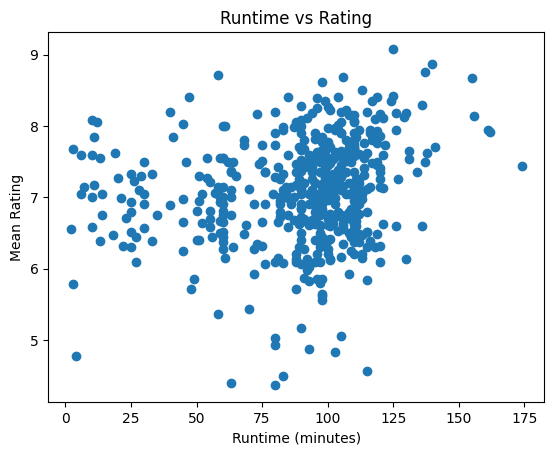

In [ ]:
def runtime_scatter_plot(csv):
    data = loading_data(csv)
    plt.scatter(data['runtime'], data['avg_score'])
    plt.xlabel("Runtime (minutes)")
    plt.ylabel("Mean Rating")
    plt.title("Runtime vs Rating")
    plt.show()

runtime_scatter_plot(csv.copy())

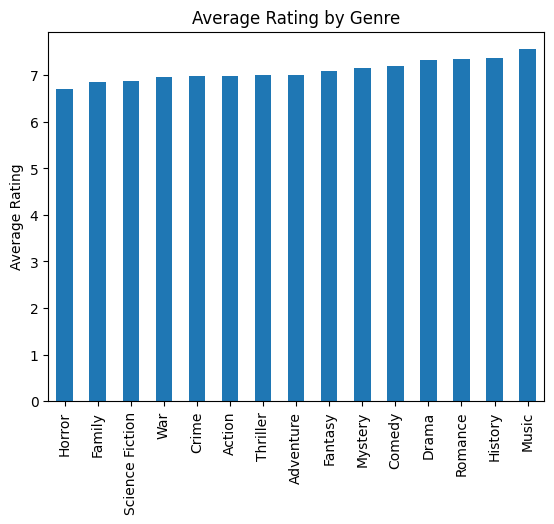

In [ ]:
def genre_bar_chart_rating(csv):
    data = loading_data(csv)
    genre_means = {}

    genre_dummies = exploding_genre(csv.copy())
    for g in genre_dummies.columns:
    
        genre_means[g] = data[data[g] == 1]['avg_score'].mean()
    
    pd.Series(genre_means).sort_values().plot(kind='bar')
    
    plt.ylabel("Average Rating")
    plt.title("Average Rating by Genre")
    plt.show()

genre_bar_chart_rating(csv)

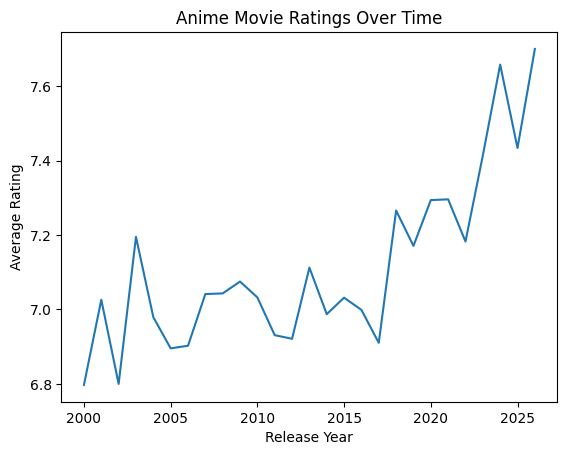

In [17]:
def ratings_over_time_plot(csv):
    data = loading_data(csv)
    year_means = data.groupby('release_year')["avg_score"].mean()

    year_means.plot()

    plt.xlabel("Release Year")
    plt.ylabel("Average Rating")
    plt.title("Anime Movie Ratings Over Time")
    plt.show()

ratings_over_time_plot(csv)

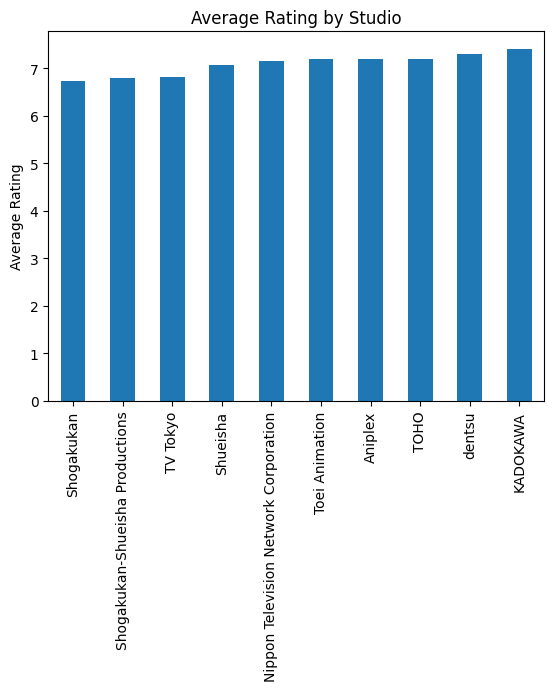

In [20]:
def ratings_over_top_studios(csv, studios_amount = 10):
    data = loading_data(csv)

    studio_scores = {}

    top_studios = exploding_studio(data)
    for s in top_studios:
        studio_scores[s] = data[data[s] == 1]['avg_score'].mean()

    pd.Series(studio_scores).sort_values().plot(kind="bar")

    plt.ylabel("Average Rating")
    plt.title("Average Rating by Studio")
    plt.show()

ratings_over_top_studios(csv)